In [ ]:
#What I added
import spacy
import pandas as pd
from collections import defaultdict
import difflib

# ==== 句子切分器（只用于拿整句文本和句内相对偏移）====
_nlp_sent = spacy.blank("en")
_nlp_sent.add_pipe("sentencizer")

def _doc_sents(doc):
    return [(s.start_char, s.end_char, s.text) for s in _nlp_sent(doc.text).sents]

In [ ]:
def eval_pred(gold, pred, case_id=None):
    M, C, S, N = 0, 0, 0, 0  # Initialize counts
    label_counts = defaultdict(lambda: {"M": 0, "C": 0, "S": 0, "N": 0})
    if True:
        # Convert entity labels to lowercase for case-insensitive comparison
        gold_ents = list(gold)
        pred_ents = list(pred)
        pred_flag = [False] * len(pred_ents)
        sorted_pred_ents = sorted(pred_ents, key=lambda x: (int(x[0]), int(x[1])))
        sorted_gold_ents = sorted(gold_ents, key=lambda x: (int(x[0]), int(x[1])))
        M_temp = 0
        C_temp = 0
        # Calculate the number of exact matches, partial matches, false positives, and false negatives
        for gold_ent in sorted_gold_ents:
            totally_match_found = False
            partial_match_found = False
            for ind1 in range(len(sorted_pred_ents)):
                pred_ent = sorted_pred_ents[ind1]
                if pred_ent[0] == gold_ent[0] and pred_ent[1] == gold_ent[1] and pred_ent[2] == gold_ent[2]:
                    totally_match_found = True
                    pred_flag[ind1] = True
                    M += 1
                    M_temp += 1
                    label_counts[gold_ent[2]]["M"] += 1
                    break
                elif pred_ent[0] == gold_ent[0] or pred_ent[1] == gold_ent[1] or gold_ent[0] < pred_ent[0] < gold_ent[1] or gold_ent[0] < pred_ent[1] < gold_ent[1] or (pred_ent[0] < gold_ent[0] and pred_ent[1] > gold_ent[0]):
                    if not pred_flag[ind1]:
                        partial_match_found = True
                        pred_flag[ind1] = True
                        C += 1
                        C_temp += 1
                        label_counts[gold_ent[2]]["C"] += 1
                        break
            if not (totally_match_found or partial_match_found):
                N += 1
                label_counts[gold_ent[2]]["N"] += 1
        S += len(sorted_pred_ents) - M_temp - C_temp
        for ind1 in range(len(sorted_pred_ents)):
            if not pred_flag[ind1]:
                label_counts[sorted_pred_ents[ind1][2]]["S"] += 1
    # Revised M', C', S', N'
    M_ = M + (0.5 * C)
    C_ = 0.5 * C
    S_ = 0.25 * S
    N_ = N
    # Compute revised Precision / Recall / F1
    precision = M_ / (M_ + C_ + S_) if (M_ + C_ + S_) > 0 else 0
    recall = M_ / (M_ + C_ + N_) if (M_ + C_ + N_) > 0 else 0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    # Compute metrics for each label type
    label_metrics = []
    for label, counts in label_counts.items():
        M_l = counts["M"]
        C_l = counts["C"]
        S_l = counts["S"]
        N_l = counts["N"]
        M_l_ = M_l + (0.5 * C_l)
        C_l_ = 0.5 * C_l
        S_l_ = 0.25 * S_l
        N_l_ = N_l
        precision_l = M_l_ / (M_l_ + C_l_ + S_l_) if (M_l_ + C_l_ + S_l_) > 0 else 0
        recall_l = M_l_ / (M_l_ + C_l_ + N_l_) if (M_l_ + C_l_ + N_l_) > 0 else 0
        f1_l = (2 * precision_l * recall_l) / (precision_l + recall_l) if (precision_l + recall_l) > 0 else 0
        label_metrics.append({
            'case_id':case_id,
            'label':label,
            "precision": precision_l,
            "recall": recall_l,
            "f1": f1_l,
            "Matched":M_l,
            "Partially Matched":C_l,
            "Missed":N_l,
            "FP":S_l
        })
    return label_metrics

In [ ]:


# ==== 句子对齐：先 exact，必要时可开 fuzzy ====
def align_sentences_both(docs_pred, docs_gold, fuzzy=False, fuzzy_threshold=0.92):
    """
    返回：
      pairs: [(p_doc_i, p_sent_i, p_sent_info), (g_doc_j, g_sent_j, g_sent_info)] 的列表
      unmatched_gold: [(g_doc_j, g_sent_j, g_sent_info)] gold 侧未对齐句
      unmatched_pred: [(p_doc_i, p_sent_i, p_sent_info)] pred 侧未对齐句
    """
    # 预处理两侧句子
    pred_index = defaultdict(list)  # text -> [(di, si, (start,end,text))]
    pred_all = []  # [(di, si, (start,end,text))]
    for di, dp in enumerate(docs_pred):
        sents = _doc_sents(dp)
        for si, s in enumerate(sents):
            pred_index[s[2]].append((di, si, s))
            pred_all.append((di, si, s))
    gold_all = []  # [(gj, sj, (start,end,text))]
    for gj, dg in enumerate(docs_gold):
        sents = _doc_sents(dg)
        for sj, s in enumerate(sents):
            gold_all.append((gj, sj, s))
    used_pred = set()
    used_gold = set()
    pairs = []
    # 1) exact
    for gj, sj, gs in gold_all:
        if (gj, sj) in used_gold:
            continue
        candidates = pred_index.get(gs[2], [])
        picked = None
        for (di, si, ps) in candidates:
            if (di, si) in used_pred:
                continue
            picked = (di, si, ps)
            break
        if picked is not None:
            pairs.append(((picked[0], picked[1], picked[2]), (gj, sj, gs)))
            used_pred.add((picked[0], picked[1]))
            used_gold.add((gj, sj))
    # 2) fuzzy（可选）
    if fuzzy:
        for gj, sj, gs in gold_all:
            if (gj, sj) in used_gold:
                continue
            best = None
            best_score = 0.0
            for di, si, ps in pred_all:
                if (di, si) in used_pred:
                    continue
                score = difflib.SequenceMatcher(None, ps[2], gs[2]).ratio()
                if score > best_score:
                    best = (di, si, ps)
                    best_score = score
            if best and best_score >= fuzzy_threshold:
                pairs.append(((best[0], best[1], best[2]), (gj, sj, gs)))
                used_pred.add((best[0], best[1]))
                used_gold.add((gj, sj))
    # 未对齐的 gold / pred 句子
    unmatched_gold = []
    for gj, sj, gs in gold_all:
        if (gj, sj) not in used_gold:
            unmatched_gold.append((gj, sj, gs))
    unmatched_pred = []
    for di, si, ps in pred_all:
        if (di, si) not in used_pred:
            unmatched_pred.append((di, si, ps))
    return pairs, unmatched_gold, unmatched_pred

# ==== 把句内实体转为相对偏移（便于在不同 doc 上对比）====
def ents_in_sentence_relative(doc, sent_start, sent_end):
    triples = []
    for ent in doc.ents:
        if ent.start_char >= sent_start and ent.end_char <= sent_end:
            triples.append((ent.start_char - sent_start,
                            ent.end_char - sent_start,
                            ent.label_))
    return triples


# ==== 匹配工具 ====
def _overlap_len(a0, a1, b0, b1):
    return max(0, min(a1, b1) - max(a0, b0))


def match_gold_pred_in_sentence(text, gold_tris, pred_tris):
    """
    在一个句子里对齐 gold/pred 实体，返回多行记录：
      match_type ∈ {'M','C','N','S'}
      并带上 gold/pred 的 start/end/text/label
    """
    rows = []
    pred_flag = [False]*len(pred_tris)
    # 先 gold 驱动：优先 exact，再选重叠最长的 partial
    for g0, g1, glab in sorted(gold_tris, key=lambda x:(x[0], x[1])):
        exact_idx = None
        best_partial_idx = None
        best_ov = 0
        for j, (p0, p1, plab) in enumerate(sorted(pred_tris, key=lambda x:(x[0], x[1]))):
            if pred_flag[j]:
                continue
            if (p0 == g0) and (p1 == g1) and (plab == glab):
                exact_idx = j
                break
            # 部分匹配判定（与你的C一致）
            if (p0 == g0) or (p1 == g1) or (g0 < p0 < g1) or (g0 < p1 < g1) or (p0 < g0 < p1):
                ov = _overlap_len(g0, g1, p0, p1)
                if ov > best_ov:
                    best_ov = ov
                    best_partial_idx = j
        if exact_idx is not None:
            p0, p1, plab = pred_tris[exact_idx]
            pred_flag[exact_idx] = True
            rows.append({
                "match_type": "M",
                "label_gold": glab, "gold_start": g0, "gold_end": g1, "gold_text": text[g0:g1],
                "label_pred": plab, "pred_start": p0, "pred_end": p1, "pred_text": text[p0:p1],
            })
        elif best_partial_idx is not None:
            p0, p1, plab = pred_tris[best_partial_idx]
            pred_flag[best_partial_idx] = True
            rows.append({
                "match_type": "C",
                "label_gold": glab, "gold_start": g0, "gold_end": g1, "gold_text": text[g0:g1],
                "label_pred": plab, "pred_start": p0, "pred_end": p1, "pred_text": text[p0:p1],
            })
        else:
            rows.append({
                "match_type": "N",
                "label_gold": glab, "gold_start": g0, "gold_end": g1, "gold_text": text[g0:g1],
                "label_pred": None, "pred_start": None, "pred_end": None, "pred_text": None,
            })
    # 剩余未用到的 pred → S
    for j, (p0, p1, plab) in enumerate(pred_tris):
        if pred_flag[j]:
            continue
        rows.append({
            "match_type": "S",
            "label_gold": None, "gold_start": None, "gold_end": None, "gold_text": None,
            "label_pred": plab, "pred_start": p0, "pred_end": p1, "pred_text": text[p0:p1],
        })
    return rows


# ==== 构建 df_align：把 LLM(docs1) & SME(docs2) 对齐到明细表 ====
def build_df_align_from_spacy(docs_llm, docs_sme, fuzzy=False, fuzzy_threshold=0.92):
    """
    输出 DataFrame 列包含：
      doc_id_pred, sent_id_pred, doc_id_gold, sent_id_gold, sentence_gold, sentence_pred,
      match_type, gold/pred start/end/text/label
    """
    pairs, unmatched_gold, unmatched_pred = align_sentences_both(
        docs_pred=docs_llm, docs_gold=docs_sme, fuzzy=fuzzy, fuzzy_threshold=fuzzy_threshold
    )
    all_rows = []
    # 已对齐的句子：句内相对偏移对齐
    for (di, si, (ps0, ps1, ptxt)), (gj, sj, (gs0, gs1, gtxt)) in pairs:
        # gold 用 gold 句文本、pred 用 pred 句文本，各自句内偏移
        gold_tris = ents_in_sentence_relative(docs_sme[gj], gs0, gs1)
        pred_tris = ents_in_sentence_relative(docs_llm[di], ps0, ps1)
        rows = match_gold_pred_in_sentence(gtxt, gold_tris, pred_tris)  # 用 gold 句文本取片段
        for r in rows:
            r.update({
                "doc_id_pred": di, "sent_id_pred": si, "sentence_pred": ptxt,
                "doc_id_gold": gj, "sent_id_gold": sj, "sentence_gold": gtxt,
            })
        all_rows.extend(rows)
    # gold 未对齐句：全算 N
    for (gj, sj, (gs0, gs1, gtxt)) in unmatched_gold:
        gold_tris = ents_in_sentence_relative(docs_sme[gj], gs0, gs1)
        for (g0, g1, glab) in gold_tris:
            all_rows.append({
                "doc_id_pred": None, "sent_id_pred": None, "sentence_pred": None,
                "doc_id_gold": gj, "sent_id_gold": sj, "sentence_gold": gtxt,
                "match_type": "N",
                "label_gold": glab, "gold_start": g0, "gold_end": g1, "gold_text": gtxt[g0:g1],
                "label_pred": None, "pred_start": None, "pred_end": None, "pred_text": None,
            })
    # pred 未对齐句：全算 S
    for (di, si, (ps0, ps1, ptxt)) in unmatched_pred:
        pred_tris = ents_in_sentence_relative(docs_llm[di], ps0, ps1)
        for (p0, p1, plab) in pred_tris:
            all_rows.append({
                "doc_id_pred": di, "sent_id_pred": si, "sentence_pred": ptxt,
                "doc_id_gold": None, "sent_id_gold": None, "sentence_gold": None,
                "match_type": "S",
                "label_gold": None, "gold_start": None, "gold_end": None, "gold_text": None,
                "label_pred": plab, "pred_start": p0, "pred_end": p1, "pred_text": ptxt[p0:p1],
            })
    df_align = pd.DataFrame(all_rows, columns=[
        "doc_id_pred", "sent_id_pred", "doc_id_gold", "sent_id_gold",
        "sentence_gold", "sentence_pred",
        "match_type",
        "label_gold", "gold_start", "gold_end", "gold_text",
        "label_pred", "pred_start", "pred_end", "pred_text",
    ])
    return df_align


def load_spacy_file(file_path):
    """Load a .spacy file and return a list of Doc objects"""
    nlp = spacy.blank("en")
    doc_bin = DocBin().from_disk(file_path)
    return list(doc_bin.get_docs(nlp.vocab))

from spacy.tokens import DocBin

# 载入两份 .spacy
docs_llm = load_spacy_file("total_FAVERS_R1_v1_LLM_new_revision.spacy")   # 作为 pred
# docs_ether = load_spacy_file("valid_FAVERS_R1_v1_ETHER_new_revision.spacy")
docs_sme = load_spacy_file("total_FAVERS_R1_v1_SME1_new_revision.spacy")  # 作为 gold

# 生成 df_align；先关掉 fuzzy，确保精确对齐更稳，再按需打开
df_align1 = build_df_align_from_spacy(docs_llm, docs_sme, fuzzy=False)

# df_align2 = build_df_align_from_spacy(docs_ether, docs_sme, fuzzy=False)

# 看前几行（显示全部列）
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
print(df_align1.head(20))

# 只看漏检 N：
print(df_align1[df_align1["match_type"]=="N"].head(20))

# 保存
# df_align.to_csv("df_align_llm_vs_sme.csv", index=False)


In [ ]:
#What I added
import spacy
import pandas as pd
from collections import defaultdict
import difflib

# ==== 句子切分器（只用于拿整句文本和句内相对偏移）====
_nlp_sent = spacy.blank("en")
_nlp_sent.add_pipe("sentencizer")

def _doc_sents(doc):
    return [(s.start_char, s.end_char, s.text) for s in _nlp_sent(doc.text).sents]

def normalize_entity_label(label: str) -> str:
    label = label.lower()
    if label in ['drug', 'cdrug', 'sdrug']:
        return 'drug'
    elif label in ['mhx', 'fhx', 'hx']:
        return 'hx'
    elif label in ['ae', 'mae']:
        return 'ae'
    elif label in ['ro', 'r/o']:
        return 'ro'
    elif label in ['second_level_diagnosis', 'diagnostic', 'symptom']:
        return 'ae'
    elif label in ['cause_of_death']:
        return 'cod'
    elif label in ['medical_history']:
        return 'medical history'
    else:
        return label


def ents_in_sentence_relative(doc, sent_start, sent_end, label_mapper=None):
    triples = []
    for ent in doc.ents:
        if ent.start_char >= sent_start and ent.end_char <= sent_end:
            lab = ent.label_
            if label_mapper is not None:
                lab = label_mapper(lab)
            triples.append((ent.start_char - sent_start,
                            ent.end_char - sent_start,
                            lab))
    return triples

# ==== 构建 df_align：允许对 pred/gold 侧分别指定映射 ====
def build_df_align_from_spacy(docs_llm, docs_sme, fuzzy=False, fuzzy_threshold=0.92,
                              mapper_pred=None, mapper_gold=None):
    """
    输出 DataFrame 列包含：
      doc_id_pred, sent_id_pred, doc_id_gold, sent_id_gold, sentence_gold, sentence_pred,
      match_type, gold/pred start/end/text/label
    """
    pairs, unmatched_gold, unmatched_pred = align_sentences_both(
        docs_pred=docs_llm, docs_gold=docs_sme, fuzzy=fuzzy, fuzzy_threshold=fuzzy_threshold
    )
    all_rows = []
    # 已对齐的句子：句内相对偏移对齐
    for (di, si, (ps0, ps1, ptxt)), (gj, sj, (gs0, gs1, gtxt)) in pairs:
        gold_tris = ents_in_sentence_relative(docs_sme[gj], gs0, gs1, label_mapper=mapper_gold)
        pred_tris = ents_in_sentence_relative(docs_llm[di], ps0, ps1, label_mapper=mapper_pred)
        rows = match_gold_pred_in_sentence(gtxt, gold_tris, pred_tris)  # 用 gold 句文本取片段
        for r in rows:
            r.update({
                "doc_id_pred": di, "sent_id_pred": si, "sentence_pred": ptxt,
                "doc_id_gold": gj, "sent_id_gold": sj, "sentence_gold": gtxt,
            })
        all_rows.extend(rows)
    # gold 未对齐句：全算 N
    for (gj, sj, (gs0, gs1, gtxt)) in unmatched_gold:
        gold_tris = ents_in_sentence_relative(docs_sme[gj], gs0, gs1, label_mapper=mapper_gold)
        for (g0, g1, glab) in gold_tris:
            all_rows.append({
                "doc_id_pred": None, "sent_id_pred": None, "sentence_pred": None,
                "doc_id_gold": gj, "sent_id_gold": sj, "sentence_gold": gtxt,
                "match_type": "N",
                "label_gold": glab, "gold_start": g0, "gold_end": g1, "gold_text": gtxt[g0:g1],
                "label_pred": None, "pred_start": None, "pred_end": None, "pred_text": None,
            })
    # pred 未对齐句：全算 S
    for (di, si, (ps0, ps1, ptxt)) in unmatched_pred:
        pred_tris = ents_in_sentence_relative(docs_llm[di], ps0, ps1, label_mapper=mapper_pred)
        for (p0, p1, plab) in pred_tris:
            all_rows.append({
                "doc_id_pred": di, "sent_id_pred": si, "sentence_pred": ptxt,
                "doc_id_gold": None, "sent_id_gold": None, "sentence_gold": None,
                "match_type": "S",
                "label_gold": None, "gold_start": None, "gold_end": None, "gold_text": None,
                "label_pred": plab, "pred_start": p0, "pred_end": p1, "pred_text": ptxt[p0:p1],
            })
    df_align = pd.DataFrame(all_rows, columns=[
        "doc_id_pred", "sent_id_pred", "doc_id_gold", "sent_id_gold",
        "sentence_gold", "sentence_pred",
        "match_type",
        "label_gold", "gold_start", "gold_end", "gold_text",
        "label_pred", "pred_start", "pred_end", "pred_text",
    ])
    return df_align



def load_spacy_file(file_path):
    """Load a .spacy file and return a list of Doc objects"""
    nlp = spacy.blank("en")
    doc_bin = DocBin().from_disk(file_path)
    return list(doc_bin.get_docs(nlp.vocab))

from spacy.tokens import DocBin

# 载入两份 .spacy
# docs_llm = load_spacy_file("valid_FAVERS_R1_v1_LLM_new_revision.spacy")   # 作为 pred
docs_ether = load_spacy_file("total_FAVERS_R1_v1_ETHER_new_revision.spacy")
docs_sme = load_spacy_file("total_FAVERS_R1_v1_SME1_new_revision.spacy")  # 作为 gold

# 生成 df_align；先关掉 fuzzy，确保精确对齐更稳，再按需打开
# df_align1 = build_df_align_from_spacy(docs_llm, docs_sme, fuzzy=False)

df_align2 = build_df_align_from_spacy(docs_ether, docs_sme, fuzzy=False, mapper_pred=normalize_entity_label, mapper_gold=normalize_entity_label)

# 看前几行（显示全部列）
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
print(df_align1.head(20))

# 只看漏检 N：
print(df_align1[df_align1["match_type"]=="N"].head(20))

# 保存
# df_align.to_csv("df_align_llm_vs_sme.csv", index=False)


In [ ]:
def compute_weighted_metrics(df_align: pd.DataFrame):
    """
    从 df_align 计算加权版 Precision / Recall / F1
    规则：
      M' = M + 0.5*C
      C' = 0.5*C
      S' = 0.25*S
      N' = N
    返回 overall 指标 + per-label DataFrame
    """
    # --- Overall ---
    cnt = df_align["match_type"].value_counts().to_dict()
    M = int(cnt.get("M", 0))
    C = int(cnt.get("C", 0))
    S = int(cnt.get("S", 0))
    N = int(cnt.get("N", 0))
    M_ = M + 0.5 * C
    C_ = 0.5 * C
    S_ = 0.25 * S
    N_ = N
    prec_overall = M_ / (M_ + C_ + S_) if (M_ + C_ + S_) > 0 else 0.0
    rec_overall  = M_ / (M_ + C_ + N_) if (M_ + C_ + N_) > 0 else 0.0
    f1_overall   = (2*prec_overall*rec_overall)/(prec_overall+rec_overall) if (prec_overall+rec_overall)>0 else 0.0
    overall = {
        "M": M, "C": C, "S": S, "N": N,
        "precision": prec_overall,
        "recall": rec_overall,
        "f1": f1_overall
    }
    # --- Per-label ---
    labels = pd.unique(pd.concat([
        df_align.loc[df_align["match_type"].isin(["M","C","N"]), "label_gold"].dropna(),
        df_align.loc[df_align["match_type"].eq("S"), "label_pred"].dropna()
    ]))
    rows = []
    for lab in labels:
        M_l = int(((df_align["match_type"]=="M") & (df_align["label_gold"]==lab)).sum())
        C_l = int(((df_align["match_type"]=="C") & (df_align["label_gold"]==lab)).sum())
        N_l = int(((df_align["match_type"]=="N") & (df_align["label_gold"]==lab)).sum())
        S_l = int(((df_align["match_type"]=="S") & (df_align["label_pred"]==lab)).sum())
        M_l_ = M_l + 0.5 * C_l
        C_l_ = 0.5 * C_l
        S_l_ = 0.25 * S_l
        N_l_ = N_l
        p_l = M_l_ / (M_l_ + C_l_ + S_l_) if (M_l_ + C_l_ + S_l_) > 0 else 0.0
        r_l = M_l_ / (M_l_ + C_l_ + N_l_) if (M_l_ + C_l_ + N_l_) > 0 else 0.0
        f1_l = (2*p_l*r_l)/(p_l+r_l) if (p_l+r_l)>0 else 0.0
        rows.append({
            "label": lab,
            "M": M_l, "C": C_l, "S": S_l, "N": N_l,
            "precision": p_l, "recall": r_l, "f1": f1_l
        })
    df_per_label = pd.DataFrame(rows).sort_values("label").reset_index(drop=True)
    return overall, df_per_label


def pretty_print_weighted(name, overall, df_per_label):
    print(f"\n===== {name} =====")
    print(f"Counts: M={overall['M']}  C={overall['C']}  S={overall['S']}  N={overall['N']}")
    print(f"Overall  P={overall['precision']:.4f}  R={overall['recall']:.4f}  F1={overall['f1']:.4f}")
    if not df_per_label.empty:
        print("\nPer-Label:")
        print(df_per_label.to_string(index=False))

overall1, df_lbl1 = compute_weighted_metrics(df_align1)
pretty_print_weighted("LLM vs SME (Weighted)", overall1, df_lbl1)

overall2, df_lbl2 = compute_weighted_metrics(df_align2)
pretty_print_weighted("ETHER vs SME (Weighted)", overall2, df_lbl2)


# overall, df_lbl = compute_weighted_metrics(df_align)
# pretty_print_weighted("ETHER vs SME (Weighted)", overall, df_lbl)

# df_align["match_type"].value_counts()
# # 保存 per-label 的指标
# df_lbl1.to_csv("per_label_LLM_weighted.csv", index=False, encoding="utf-8-sig")
# df_lbl2.to_csv("per_label_ETHER_weighted.csv", index=False, encoding="utf-8-sig")
# df_lbl.to_csv("per_label_BERT_weighted.csv", index=False, encoding="utf-8-sig")

# pd.DataFrame([overall1]).to_csv("overall_LLM_weighted.csv", index=False, encoding="utf-8-sig")
# pd.DataFrame([overall2]).to_csv("overall_ETHER_weighted.csv", index=False, encoding="utf-8-sig")
# pd.DataFrame([overall]).to_csv("overall_BERT_weighted.csv", index=False, encoding="utf-8-sig")

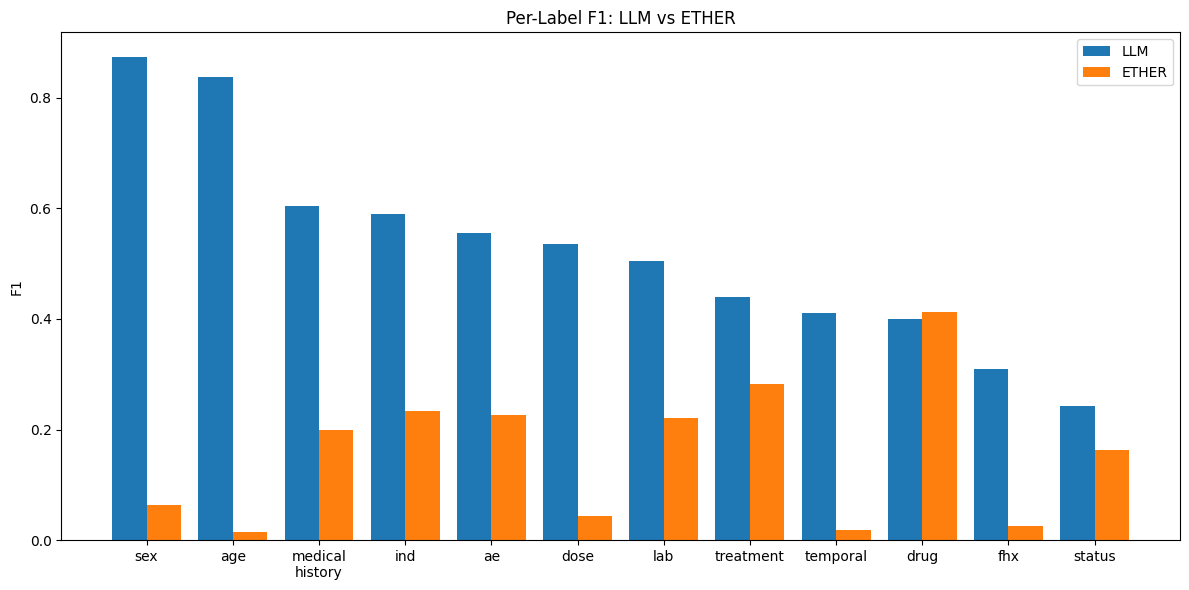

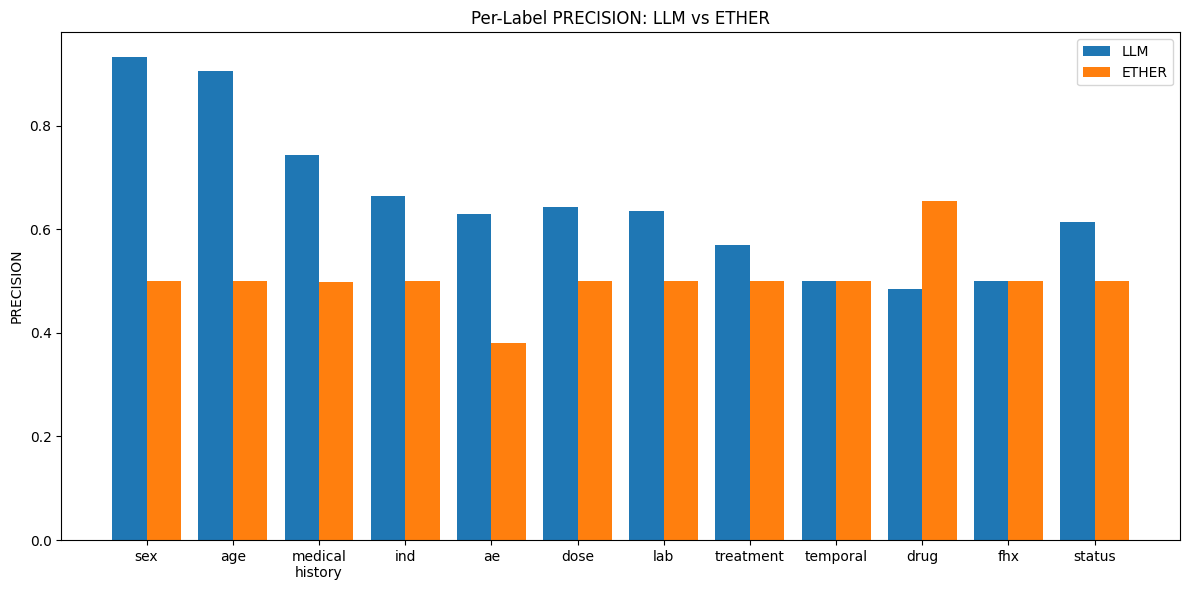

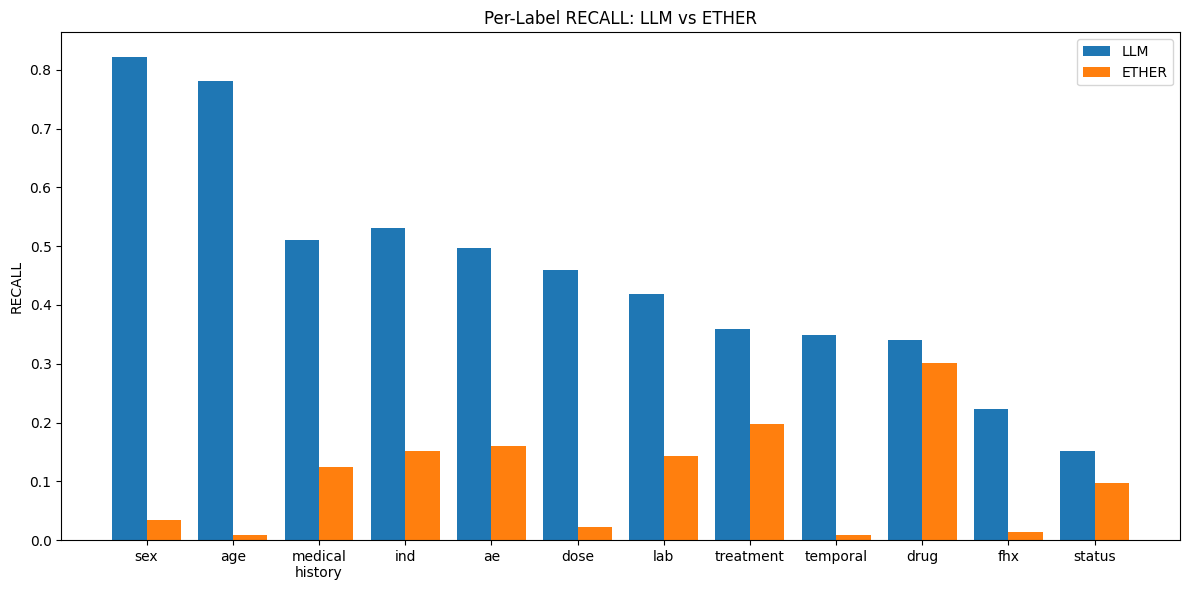

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from textwrap import wrap

# ===== 手动构建 df_lbl1（LLM 结果） =====
df_lbl1 = pd.DataFrame([
    {"label":"ae","M":2289,"C":1970,"S":3769,"N":2333,"precision":0.629464,"recall":0.496663,"f1":0.555233},
    {"label":"age","M":516,"C":64,"S":102,"N":122,"precision":0.905037,"recall":0.780627,"f1":0.838241},
    {"label":"cdrug","M":974,"C":498,"S":933,"N":642,"precision":0.717197,"recall":0.578524,"f1":0.640440},
    {"label":"cod","M":0,"C":0,"S":85,"N":0,"precision":0.0,"recall":0.0,"f1":0.0},
    {"label":"date","M":0,"C":0,"S":563,"N":0,"precision":0.0,"recall":0.0,"f1":0.0},
    {"label":"diagnostic","M":1,"C":111,"S":563,"N":152,"precision":0.223541,"recall":0.214015,"f1":0.218674},
    {"label":"dose","M":358,"C":440,"S":404,"N":459,"precision":0.642937,"recall":0.459825,"f1":0.536178},
    {"label":"drug","M":0,"C":136,"S":16,"N":64,"precision":0.485714,"recall":0.34,"f1":0.4},
    {"label":"duration","M":0,"C":0,"S":100,"N":0,"precision":0.0,"recall":0.0,"f1":0.0},
    {"label":"fhx","M":0,"C":34,"S":0,"N":42,"precision":0.5,"recall":0.223684,"f1":0.309091},
    {"label":"history","M":0,"C":0,"S":1,"N":0,"precision":0.0,"recall":0.0,"f1":0.0},
    {"label":"ind","M":187,"C":145,"S":234,"N":157,"precision":0.664533,"recall":0.530675,"f1":0.590108},
    {"label":"lab","M":659,"C":962,"S":691,"N":1097,"precision":0.63554,"recall":0.419426,"f1":0.505347},
    {"label":"mae","M":29,"C":38,"S":880,"N":97,"precision":0.167247,"recall":0.292683,"f1":0.21286},
    {"label":"medical history","M":1157,"C":759,"S":613,"N":1094,"precision":0.74254,"recall":0.510465,"f1":0.605011},
    {"label":"odrug","M":0,"C":0,"S":474,"N":0,"precision":0.0,"recall":0.0,"f1":0.0},
    {"label":"relative","M":0,"C":0,"S":33,"N":0,"precision":0.0,"recall":0.0,"f1":0.0},
    {"label":"sdrug","M":961,"C":1087,"S":2234,"N":755,"precision":0.577211,"recall":0.536746,"f1":0.556244},
    {"label":"sex","M":540,"C":24,"S":109,"N":107,"precision":0.933615,"recall":0.822653,"f1":0.874629},
    {"label":"status","M":176,"C":196,"S":297,"N":1440,"precision":0.614006,"recall":0.151214,"f1":0.242666},
    {"label":"temporal","M":3,"C":3761,"S":1,"N":1628,"precision":0.500365,"recall":0.349314,"f1":0.411413},
    {"label":"treatment","M":231,"C":511,"S":449,"N":613,"precision":0.569505,"recall":0.359041,"f1":0.440421},
])

# ===== 手动构建 df_lbl2（ETHER 结果） =====
df_lbl2 = pd.DataFrame([
    {"label":"ae","M":410,"C":1430,"S":4457,"N":5180,"precision":0.380807,"recall":0.160256,"f1":0.225581},
    {"label":"age","M":0,"C":11,"S":0,"N":691,"precision":0.5,"recall":0.007835,"f1":0.015428},
    # {"label":"cod","M":0,"C":0,"S":29,"N":0,"precision":0.0,"recall":0.0,"f1":0.0},
    {"label":"dose","M":0,"C":58,"S":0,"N":1199,"precision":0.5,"recall":0.023071,"f1":0.044106},
    {"label":"drug","M":1318,"C":453,"S":2360,"N":3346,"precision":0.654172,"recall":0.301837,"f1":0.413078},
    {"label":"hx","M":0,"C":2,"S":0,"N":74,"precision":0.5,"recall":0.013158,"f1":0.025641},
    {"label":"ind","M":0,"C":149,"S":0,"N":340,"precision":0.5,"recall":0.152352,"f1":0.233542},
    {"label":"lab","M":0,"C":774,"S":0,"N":1944,"precision":0.5,"recall":0.142384,"f1":0.221649},
    {"label":"medical history","M":14,"C":723,"S":63,"N":2273,"precision":0.498838,"recall":0.124751,"f1":0.199588},
    {"label":"sex","M":0,"C":46,"S":0,"N":625,"precision":0.5,"recall":0.034277,"f1":0.064156},
    {"label":"status","M":0,"C":353,"S":0,"N":1459,"precision":0.5,"recall":0.097406,"f1":0.163048},
    {"label":"temporal","M":0,"C":101,"S":0,"N":5291,"precision":0.5,"recall":0.009366,"f1":0.018387},
    {"label":"treatment","M":0,"C":533,"S":0,"N":822,"precision":0.5,"recall":0.196679,"f1":0.282309},
])

# ===== 把 hx 映射成 fhx，方便和 df_lbl1 对齐 =====
df_lbl2["label"] = df_lbl2["label"].replace({"hx": "fhx"})

# ===== 合并两个结果，便于画对比图 =====
metrics = ["precision", "recall", "f1"]
merged = df_lbl1[["label"]+metrics].merge(df_lbl2[["label"]+metrics], on="label", suffixes=("_llm", "_ether"))
merged = merged.sort_values("f1_llm", ascending=False)

# ===== 画对比柱状图 =====
def plot_metric(metric):
    plt.figure(figsize=(12,6))
    x = range(len(merged))
    barw = 0.4
    plt.bar([i-barw/2 for i in x], merged[f"{metric}_llm"], width=barw, label="LLM")
    plt.bar([i+barw/2 for i in x], merged[f"{metric}_ether"], width=barw, label="ETHER")
    plt.xticks(list(x), ['\n'.join(wrap(l, 14)) for l in merged["label"]], rotation=0)
    plt.ylabel(metric.upper())
    plt.title(f"Per-Label {metric.upper()}: LLM vs ETHER")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_metric("f1")
plot_metric("precision")
plot_metric("recall")
